In [2]:
import sys
sys.path.append('../modules')

In [9]:
from bsts import BSTSForCausalInferenceWrapper
from assets_etl import *

import pandas as pd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
ticker2permno = {
    "TSLA": 93436
}

start_date = "2011-01-01"
end_date   = "2020-12-31"

In [47]:
# load data
wrds_loader = WRDSLoader(username="farouk_b")
# wrds_loader.download_stock_data(ticker2permno, from_=start_date, to=end_date, save_to="../data/stocks/", close_conn=False)
# wrds_loader.download_rf_data(start_date, end_date, save_to="../data/risk-free/", close_conn=False)
# wrds_loader.download_market_pf_data(start_date, end_date, save_to="../data/factors/", close_conn=False)
# wrds_loader.download_sp500_data(start_date, end_date, save_to="../data/index/", close_conn=False)
wrds_loader.close()

Loading library list...
Done


## BSTS ANALYSIS ON STOCKS

In [4]:
# process stocks
stocks = {}
stocks["TSLA"] = preprocess_tsla(read_from="../data/stocks/TSLA_2011_2020.csv")
# process risk-free rate
rf_df = preprocess_rf(read_from="../data/risk-free/rf_2011_2020.csv")
# process market portfolio
mkt_df = preprocess_mkt(read_from="../data/factors/market_2011_2020.csv")

In [56]:
pre_effect_lag_window  = 30 # days
post_effect_lag_window = 5  # days

models = {}
for ticker, stock_df in stocks.items():
    data = merge_data(stock_df, rf_df, mkt_df)
    
for tweet in tweets:
    tweet_id, tweet_date, _ = tweet
    models[tweet_id] = {}
        
    data, effect_lag = prepare_for_bsts(data, tweet_date)
        
    bsts_model = BSTSForCausalInferenceWrapper(data=data)
    bsts_model.fit(effect_lag, pre_effect_lag_window, post_effect_lag_window)
        
    models[tweet_id][ticker] = bsts_model

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.39848D+00    |proj g|=  1.32602D-01

At iterate    5    f=  1.37973D+00    |proj g|=  3.37976D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      6      8      1     0     0   2.523D-06   1.380D+00
  F =   1.3797270750660526     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


 This problem is unconstrained.


In [57]:
models["tweet_id"]["TSLA"].summary()

                                  Average         Cumulative
Actual                                  0                  0
Predicted                               0                  0
95% CI                             [0, 0]             [0, 0]
                                                            
Absolute Effect                         0                  0
95% CI                             [0, 0]             [0, 0]
                                                            
Relative Effect                   -145.5%            -145.5%
95% CI                  [-479.7%, 188.6%]  [-479.7%, 188.6%]
                                                            
P-value                             72.1%                   
Prob. of Causal Effect              27.9%                   
None


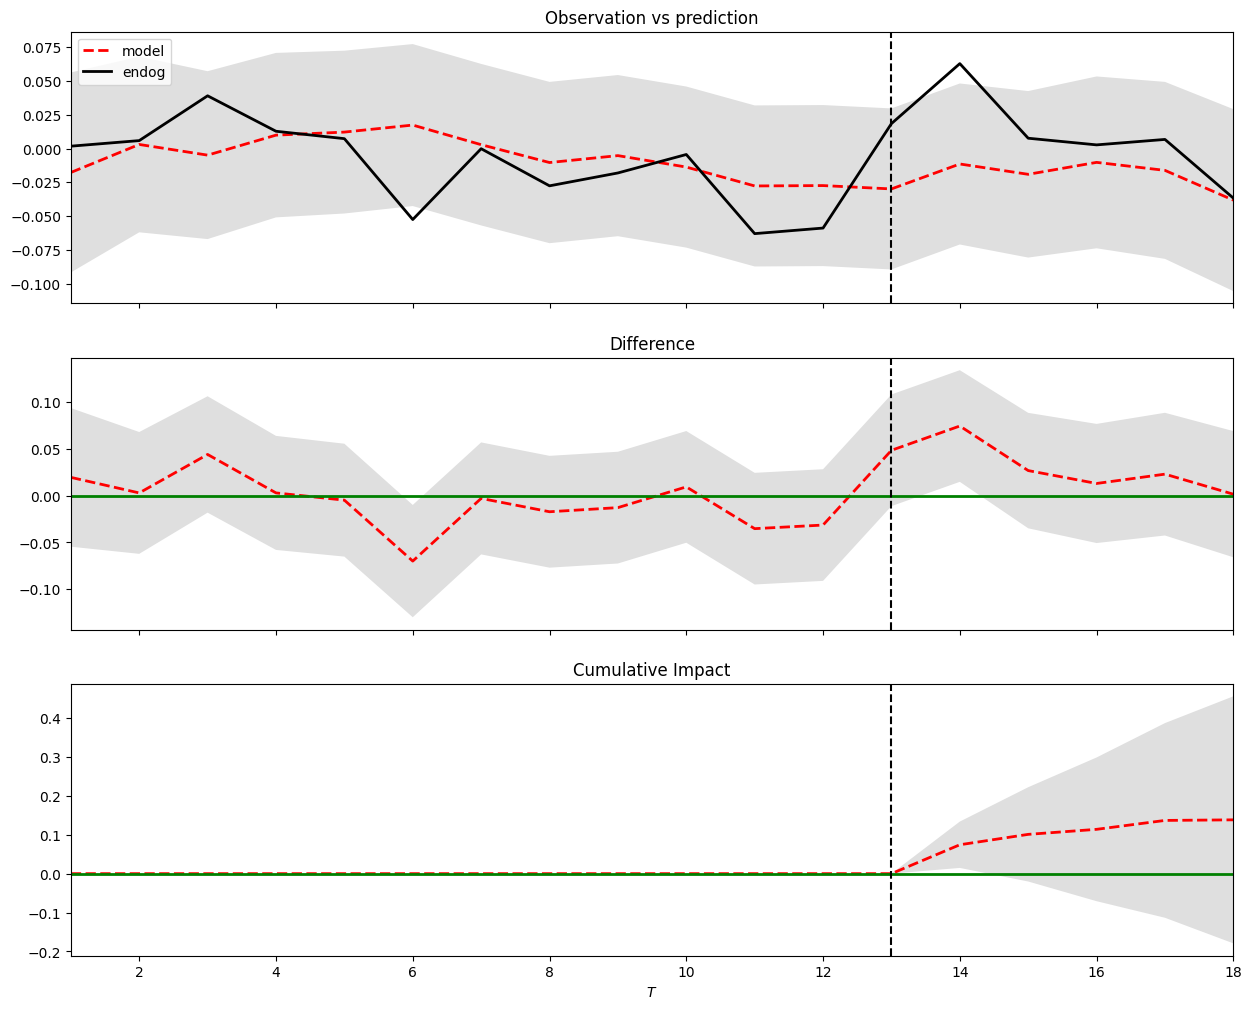

In [58]:
models["tweet_id"]["TSLA"].plot()